# Initial Setup





In [3]:
import random
import numpy as np
import tensorflow as tf

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Global random seeds are set before any other imports or operations to ensure reproducibility across runs. This controls randomness in Python, NumPy, and TensorFlow — covering all sources of stochasticity in the training pipeline, including weight initialization and data shuffling.

In [3]:
import os

import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import seaborn as sns
from matplotlib import pyplot as plt

labels = pd.read_csv('../data/labels.csv')

train_datagen = ImageDataGenerator(rescale=1./255,
                                   horizontal_flip=True,
                                   rotation_range=15)


train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe=labels,
    directory='../data/final_files',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    seed=12345)

Found 7591 validated image filenames.


## Preprocessing and EDA  📈

In [5]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [6]:
labels.sample(5)

,file_name,real_age
5370,005370.jpg,50
4516,004516.jpg,41
3968,003968.jpg,46
2188,002188.jpg,85
5833,005833.jpg,14


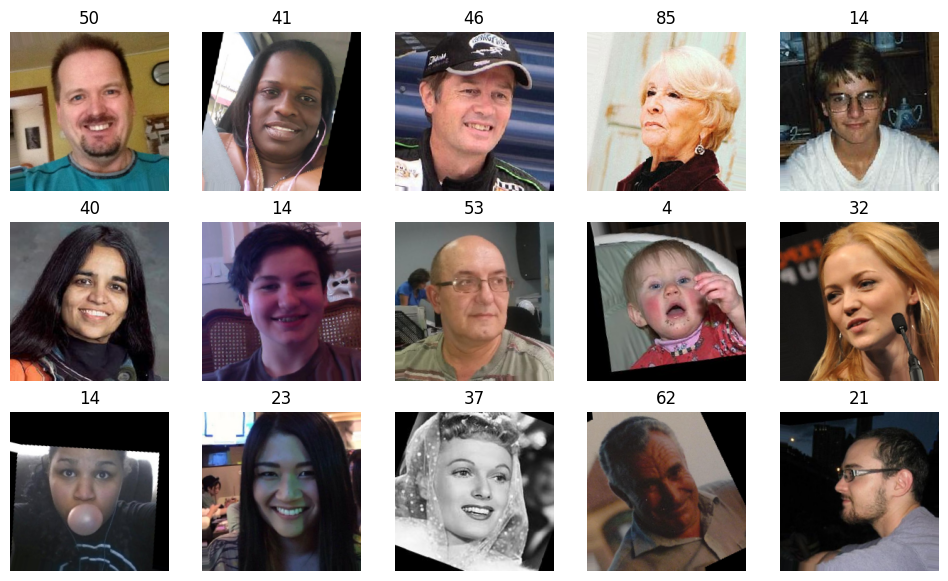

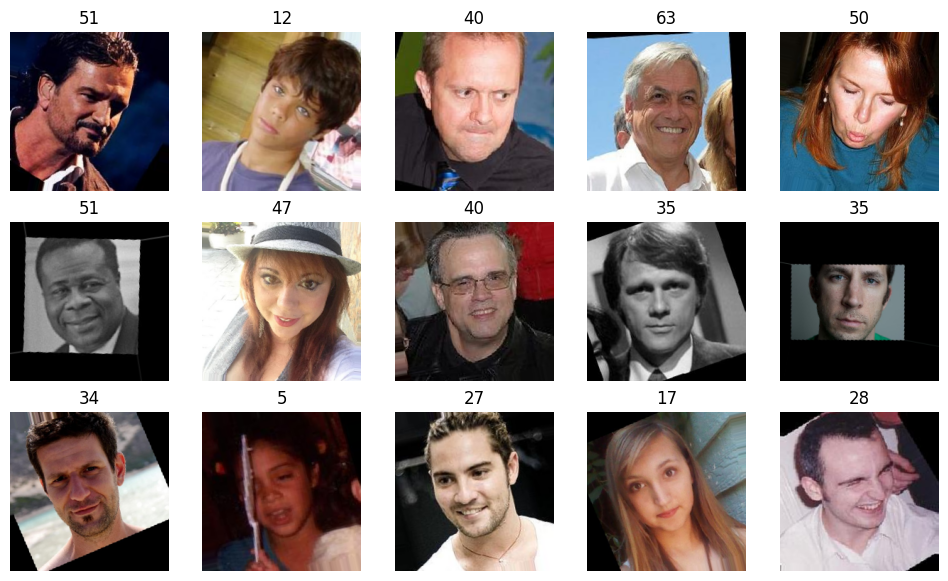

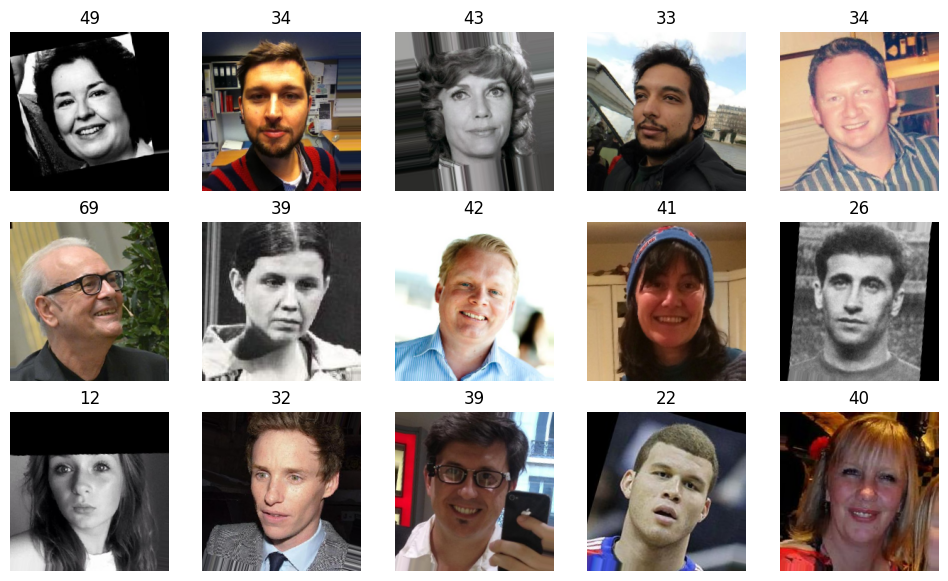

In [7]:
for _ in range(3):
    images, ages = next(train_gen_flow)

    fig, axes = plt.subplots(3,5, figsize=(12,7))

    for i in range(15):
        axes[i//5, i%5].imshow(images[i])
        axes[i//5, i%5].set_title(int(ages[i]))
        axes[i//5, i%5].axis("off")

    plt.show()

Upon manual inspection, 1 slightly distorted image was identified out of 7,600 total (<0.01%), representing a minimal impact on model training.

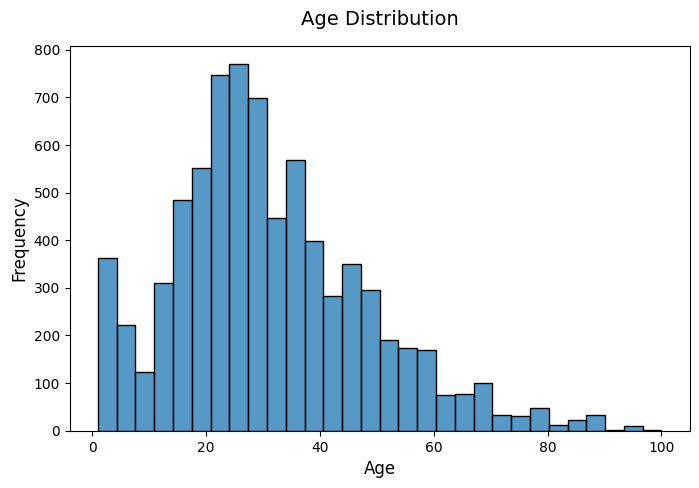

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(data=labels, x='real_age', bins=30)
plt.title("Age Distribution", fontsize=14, pad=15)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

In [9]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


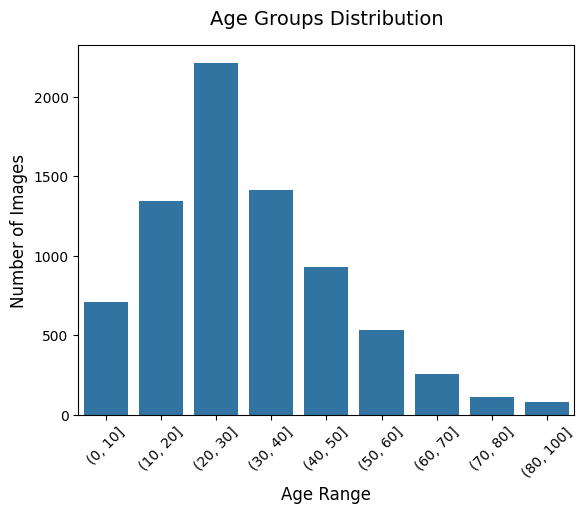

In [10]:
# Grouped age distribution analysis

age_group = pd.cut(
    labels['real_age'],
    bins=[0,10,20,30,40,50,60,70,80,100]
)

counts = age_group.value_counts().sort_index()

sns.barplot(
    x=counts.index.astype(str),
    y=counts.values
)

plt.title("Age Groups Distribution", fontsize=14, pad=15)
plt.xlabel("Age Range", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)

plt.show()

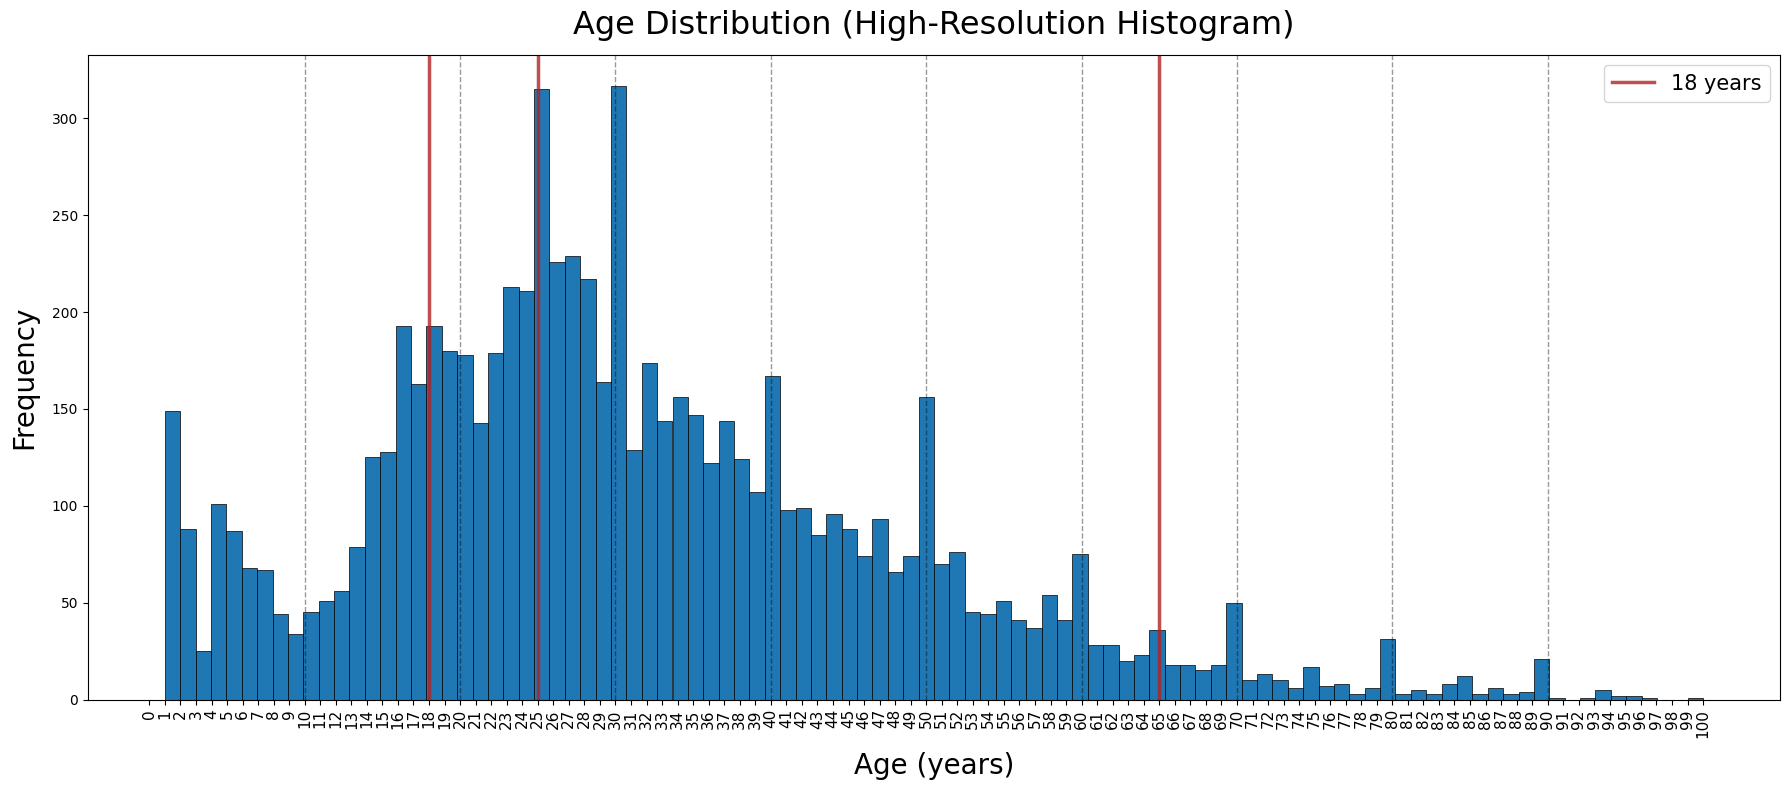

In [11]:
# Increase the number of bins to inspect potential rounding bias in age labels.

plt.figure(figsize=(18, 8))

sns.histplot(
    data=labels,
    x='real_age',
    bins=100,
    linewidth=0.5,
    alpha=1
)

plt.title("Age Distribution (High-Resolution Histogram)", fontsize=23, pad=15)
plt.xlabel("Age (years)", fontsize=20, labelpad=10)
plt.ylabel("Frequency", fontsize=20, labelpad=10)

plt.xticks(range(0, 101), rotation=90, fontsize=11)

milestone_ages = [18, 25, 65]
decade_ages = [10, 20, 30, 40, 50, 60, 70, 80, 90]

for age in decade_ages:
    plt.axvline(x=age, color='black', linestyle='--', alpha=0.4, linewidth=1)

for age in milestone_ages:
    label_text = f'{age} years' if age == 18 else ""
    plt.axvline(x=age, color='firebrick', linestyle='-',
                alpha=0.8, linewidth=2.5, label=label_text)

plt.legend(fontsize=15)

plt.tight_layout()
plt.show()

Rounding bias detected, but distribution favorable for the objective: The analysis reveals a rounding bias in decade ages (30, 40, 50), suggesting human estimation in the labeling process. However, the distribution around age 18 is natural and sufficiently dense, allowing the model to learn the legal threshold for alcohol sales with greater reliability.

Although data between ages 10 and 17 is less frequent, this favors a conservative approach where it is preferable to generate false positives (requesting ID from young adults) rather than false negatives.

In [ ]:
sizes = []

for img_name in labels['file_name'].sample(200):
    img = Image.open('../data/final_files/' + img_name)
    sizes.append(img.size)

pd.Series(sizes).value_counts().head()

,count
"(138, 138)",2
"(628, 628)",2
"(214, 215)",2
"(331, 331)",2
"(233, 233)",2


All images in the sample are square (width and height are equal, e.g.: 165×165, 504×504), which is convenient for preprocessing as there will be no distortion when resizing to 224×224.

In [ ]:
missing = []

for img in labels['file_name']:
    if not os.path.exists('../data/final_files/' + img):
        missing.append(img)

print("Missing images:", len(missing))

Missing images: 0


In [14]:
mean_age = labels['real_age'].mean()

mse_baseline = ((labels['real_age'] - mean_age) ** 2).mean()
mae_baseline = abs(labels['real_age'] - mean_age).mean()


print(f"Baseline MAE: {mae_baseline:.2f}")
print(f"Baseline MSE: {mse_baseline:.2f}")
print(f"Baseline RMSE: {np.sqrt(mse_baseline):.2f}")

Baseline MAE: 13.32
Baseline MSE: 293.91
Baseline RMSE: 17.14


Using the mean age as a constant predictor establishes a baseline MAE of ~13.31 years and an RMSE of 17.14 years, the minimum performance threshold any meaningful deep learning model must surpass.

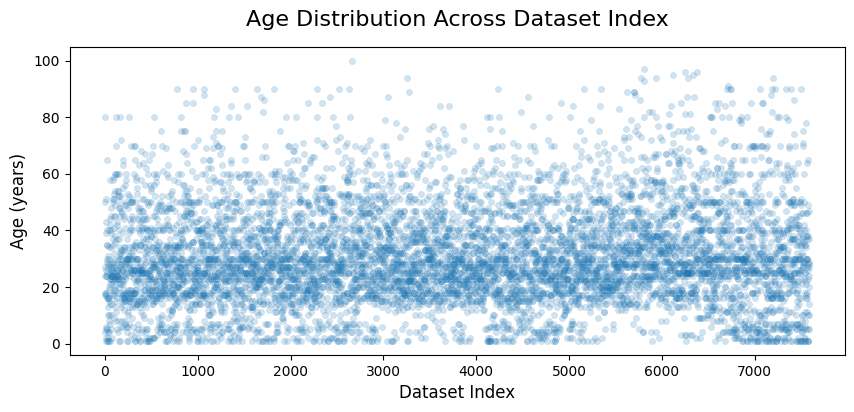

In [16]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    x=labels.index,
    y=labels['real_age'],
    alpha=0.2,
    edgecolor=None,
    s=20
)

plt.title("Age Distribution Across Dataset Index", fontsize=16, pad=15)
plt.xlabel("Dataset Index", fontsize=12)
plt.ylabel("Age (years)", fontsize=12)

plt.show()

The age distribution is skewed toward the 20–40 year range, which may reduce model precision for underrepresented age groups, particularly those over 50. However, this limitation does not compromise the project's primary objective, verifying whether an individual is of legal age for alcohol purchase.

Since the critical threshold for this task falls around age 18, the dataset's current distribution remains well-suited for training a model capable of detecting potential underage sales.

In [17]:
critical_zone = labels[(labels['real_age'] > 17) & (labels['real_age'] < 25)]

critic_zone_percent = len(critical_zone) / len(labels)

print(f"{round(critic_zone_percent * 100, 4)}%")


17.086%


Approximately 17% of the dataset corresponds to individuals between 18 and 24 years of age, providing adequate representation within the critical legal age range. This is particularly favorable for the model, as the ability to accurately distinguish individuals near the threshold of adulthood is essential to fulfilling the project's core objective: preventing alcohol sales to minors.


### General conclusion of the EDA

1. Labeling Quality: A rounding bias was detected at decadal age increments, likely reflecting human estimation during the labeling process. Despite this, the distribution around the critical 18-year threshold is sufficiently natural and dense to support reliable model training in the most relevant age verification zone.

2. Critical Representation: Approximately 17.26% of the dataset falls within the 18–24 age range, providing adequate sample coverage for the model to effectively learn to discriminate across the legal age boundary.

3. Risk Management: The lower data density in the 10–17 age bracket reinforces a conservative decision framework. From a business risk perspective, false positives, flagging a young adult for verification, are a far more acceptable outcome than false negatives, which would result in failing to identify a minor.

4. Technical Consistency: All analyzed images maintain a square aspect ratio, ensuring that no morphological distortion is introduced during the ResNet50 preprocessing pipeline when resizing to 224×224.

5. Baseline Performance: Regression metrics were computed relative to the target variable's mean to establish the minimum performance floor required for practical deployment. Any viable model must surpass a baseline MAE of 13.31 years and an RMSE of 17.14 years to demonstrate genuine predictive value.

## Computer Vision Model Development for Age Estimation

### Data Loading and Batch Processing

In [18]:
def load_train(path, labels_train):

    train_datagen = ImageDataGenerator(rescale=1./255,
                                       horizontal_flip=True,
                                       rotation_range=15)

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels_train,
        directory=path,
        x_col='file_name',
        y_col='real_age',
        shuffle=True,
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345
    )

    return train_gen_flow


In [19]:
def load_test(path, labels_test):

    test_datagen = ImageDataGenerator(rescale=1./255)

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels_test,
        directory=path,
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345
    )

    return test_gen_flow


### Initializing the RestNet50 based Model

In [20]:
def create_model(input_shape, trainable=True):

    backbone = ResNet50(weights='imagenet',
                        include_top=False,
                        input_shape=input_shape
                       )

    backbone.trainable = trainable

    model = Sequential()

    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0001)

    model.compile(loss="mse",
                  optimizer=optimizer,
                  metrics=['mae']
                 )

    return model


In [33]:
from tensorflow.keras.callbacks import EarlyStopping


def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):

    stop = EarlyStopping(monitor='val_mae', patience=3, restore_best_weights=True)

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=[stop],
        verbose=2
    )

    return model


### Data Splitting and Model Training Pipeline

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(labels, test_size=0.2, random_state=12345)

X_train = load_train('../data/final_files', train)
X_test = load_test('../data/final_files', test)

Found 6072 validated image filenames.
Found 1519 validated image filenames.


### Initial Training Results: Frozen Backbone Configuration

In [23]:
input_shape = (224, 224, 3)

model = create_model(input_shape, False)
trained_model_frozen = train_model(model, X_train, X_test, epochs=15)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
190/190 - 114s - 598ms/step - loss: 1118.6400 - mae: 28.7535 - val_loss: 1007.1642 - val_mae: 26.9815
Epoch 2/15
190/190 - 89s - 468ms/step - loss: 900.8448 - mae: 25.0787 - val_loss: 812.7426 - val_mae: 23.5288
Epoch 3/15
190/190 - 89s - 468ms/step - loss: 729.8382 - mae: 21.9371 - val_loss: 661.3527 - val_mae: 20.5513
Epoch 4/15
190/190 - 88s - 464ms/step - loss: 598.1324 - mae: 19.2202 - val_loss: 545.9865 - val_mae: 18.0291
Epoch 5/15
190/190 - 89s - 467ms/step - loss: 499.4807 - mae: 17.0546 - val_loss: 460.4114 - val_mae: 16.1110
Epoch 6/15
190/190 - 140s - 739ms/step - loss: 427.8438 - mae: 15.4832 - val_loss: 399.4609 - val_mae: 14.7922
Epoch 7/15
190/190 - 88s - 463ms/step - loss: 377.6988 - mae: 14.4016 - val_loss: 357.3407 - val_mae: 13.9053
Epoch 8/15
190/190 - 88s - 461ms/step - loss: 344.1516 - mae: 13.7022 - val_loss: 329.9116 - val_mae: 13.3796
Epoch 9/15
190/190 - 88s - 465ms/step - loss: 322.3931 - mae: 13.

### Fine-Tuning Results: Trainable Backbone Configuration

In [34]:
input_shape = (224, 224, 3)

model = create_model(input_shape, True)
trained_model_tuned = train_model(model, X_train, X_test, epochs=15)

Epoch 1/15
190/190 - 259s - 1s/step - loss: 220.1330 - mae: 10.5599 - val_loss: 1124.5234 - val_mae: 28.9540
Epoch 2/15
190/190 - 120s - 631ms/step - loss: 86.3488 - mae: 7.0020 - val_loss: 677.4048 - val_mae: 20.6545
Epoch 3/15
190/190 - 118s - 618ms/step - loss: 68.7338 - mae: 6.2990 - val_loss: 373.9260 - val_mae: 14.6222
Epoch 4/15
190/190 - 112s - 592ms/step - loss: 53.2463 - mae: 5.5911 - val_loss: 122.1108 - val_mae: 7.9584
Epoch 5/15
190/190 - 116s - 609ms/step - loss: 43.4287 - mae: 4.9955 - val_loss: 85.1128 - val_mae: 6.8033
Epoch 6/15
190/190 - 116s - 610ms/step - loss: 42.5345 - mae: 4.9943 - val_loss: 93.1169 - val_mae: 7.4472
Epoch 7/15
190/190 - 116s - 609ms/step - loss: 33.0074 - mae: 4.3984 - val_loss: 80.9831 - val_mae: 6.6674
Epoch 8/15
190/190 - 117s - 614ms/step - loss: 30.0802 - mae: 4.1721 - val_loss: 77.9343 - val_mae: 6.6178
Epoch 9/15
190/190 - 118s - 621ms/step - loss: 27.3916 - mae: 4.0328 - val_loss: 79.6607 - val_mae: 6.5362
Epoch 10/15
190/190 - 118s - 6

In [4]:
results_data = [
    {
        'Configuration': 'Frozen Backbone',
        'Epoch': '13/15',
        'Train MAE': 13.15,
        'Train RMSE': 17.21,
        'Val MAE': 13.14,
        'Val RMSE': 17.07
    },
    {
        'Configuration': 'Fine-Tuning Backbone',
        'Epoch': '11/15',
        'Train MAE': 3.27,
        'Train RMSE': 4.29,
        'Val MAE': 6.45,
        'Val RMSE': 8.75
    }
]

df_results = pd.DataFrame(results_data)

baseline_mae = 13.31
df_results['Improvement vs Baseline (%)'] = (
    (baseline_mae - df_results['Val MAE']) / baseline_mae * 100).round(2)

display(df_results)

,Configuration,Epoch,Train MAE,Train RMSE,Val MAE,Val RMSE,Improvement vs Baseline (%)
0,Frozen Backbone,13/15,13.15,17.21,13.14,17.07,1.28
1,Fine-Tuning Backbone,11/15,3.27,4.29,6.45,8.75,51.54


Fine-Tuning significantly outperforms both the Frozen Backbone and the established baseline. It achieved a Validation MAE of 6.45 years, representing an improvement of approximately 52% over the baseline.

## Conclusion


To establish a performance benchmark, a baseline model was constructed using the mean age as a constant predictor, resulting in a MAE of 13.32 years and an RMSE of 17.14 years. All subsequent models were evaluated against this reference to determine whether meaningful predictive capacity had been achieved.

The first configuration, a frozen backbone (trainable=False), employed the pretrained ResNet50 exclusively as a fixed feature extractor. This approach yielded a validation MAE of approximately 13.14 years, which is statistically indistinguishable from the baseline, indicating that the frozen representations were insufficient to capture the underlying patterns governing facial age estimation.

The second configuration introduced full backbone fine-tuning (trainable=True), allowing the pretrained weights to be updated during training. This produced a marked improvement in predictive performance, achieving a training MAE of 3.27 years and RMSE of 4.29, as well as a validation MAE of 6.45 years and RMSE of 8.75, representing an approximate 52% reduction in error relative to the baseline.

These results confirm that transfer learning with fine-tuning is an effective strategy for this task. In the context of the target business application, and automated age verification for alcohol retail, the model demonstrates sufficient precision to meaningfully support decision-making processes and mitigate the risk of non-compliant sales to minors.